LAB Lezione 2: Neural Network to perform regression on a set of data points that lie on a parabola. 

Now it's your turn! In the shared folder there is a python script you can edit.

**Goal:** The goal of this exercise is to build a neural network using PyTorch to perform regression on a set of data points that lie on a parabolic curve. The training data consists of points on the parabola defined in the range x in [-1,1] (with no noise).

**Steps**

1.   Generate data points
2.   Define a NN architecture
3.   Train the network
4.   Plot the loss
5.   Plot network's predictions and the parabola in the range [-2,2].

In [ ]:
import torch
from torch import nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


class NNParabola(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        #DEFINE HERE THE LAYERS
        self.layers = nn.Sequential(nn.Linear(input_size, 2),
              nn.Tanh(),
              nn.Linear(2, 4),
              nn.ReLU(),
              nn.Linear(4, 8),
              nn.Sigmoid(),
              nn.Linear(8,16),
              nn.ReLU(),
              nn.Linear(16, output_size),
              nn.Sigmoid())
        
        #DEFINE HERE THE OPTIMIZER
        self.optimizer = optim.Adam(self.parameters(), lr=0.01)

        #DEFINE HERE THE LOSS
        self.criterion = nn.MSELoss()

    def forward(self, x):
        #DEFINE HERE THE MODEL
        output = self.model(x)
        return output

    def train_step(self, inputs, labels):

        # zero the parameter gradients
        self.optimizer.zero_grad()

        # forward + backward + optimize
        outputs = self.forward(inputs)
        labels = labels.unsqueeze(1)

        loss = self.criterion(outputs, labels)
        loss.backward()

        self.optimizer.step()

        return loss.item()


def parabola(x, a=2, b=0, c=-1.5):
    return a*x**2 + b*x + c



def main():

    input_size = 1
    output_size = 1

    # Load the data:
    x_data, y_data = np.load('parabola.npz')['x'], np.load('parabola.npz')['y']
    # Reshape the x data as .reshape(len(x_data), 1)
    x_data = torch.tensor(x_data, dtype=torch.float32).reshape(len(x_data), 1)
    y_data = torch.tensor(y_data, dtype=torch.float32)

    # Splitting the dataset into train and test one:
    x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2)
    # Dataset loader creation:
    dataset_train = TensorDataset(x_train, y_train)
    loader_train = DataLoader(dataset_train, batch_size=50, shuffle=True)

    # Define the model
    nn_model = NNParabola(input_size, output_size)

    loss_evolution = []
    # Train the model

    n_of_epochs = 200
    for epoch, (input, label) in enumerate(zip(dataset_train, labels)):
        loss_batches = []
        for batch in loader_train:
            loss_batches = nn_model.train_step(input,label)
            print("epoch: {}, loss: {}".format(epoch+1, loss_batches))


    plt.figure(figsize=(10, 5))
    plt.plot(n_of_epochs, loss_evolution)
    plt.show()

    # plot the parabola and the predicted parabola

    # Here we don't need to compute the gradients
    with torch.no_grad():
        # TODO: generate input data in the range [-2,2] and query the NN and plot the predictions
        ...

    x = torch.linspace(-1, 1, 1000)
    x = torch.reshape(x, shape=(x.size()[0], 1))
    y = nn_model(x)

    plt.figure(figsize=(10, 5))
    plt.plot(x.detach().numpy(), y.detach().numpy())
    plt.plot(x.detach().numpy(), parabola(x))
    plt.show()


if __name__ == "__main__":
    main()

GEMINI

Inizio dell'addestramento...
Epoca:  20/200, Loss: 0.0007
Epoca:  40/200, Loss: 0.0002
Epoca:  60/200, Loss: 0.0001
Epoca:  80/200, Loss: 0.0001
Epoca: 100/200, Loss: 0.0001
Epoca: 120/200, Loss: 0.0001
Epoca: 140/200, Loss: 0.0001
Epoca: 160/200, Loss: 0.0001
Epoca: 180/200, Loss: 0.0001
Epoca: 200/200, Loss: 0.0001


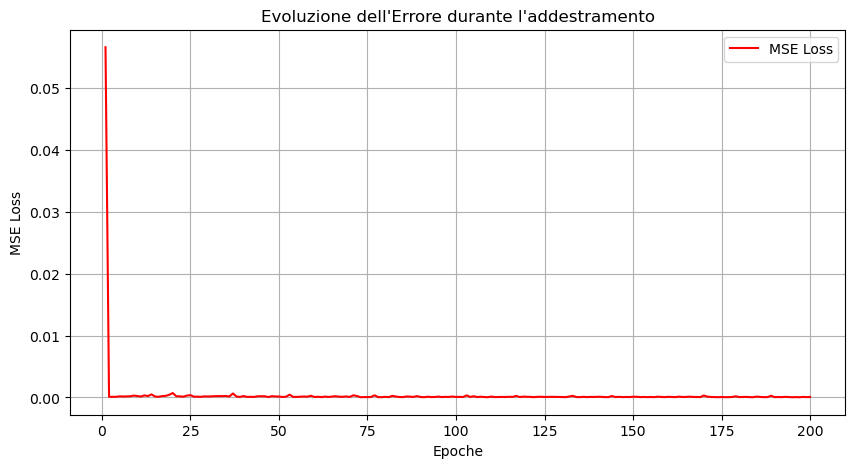

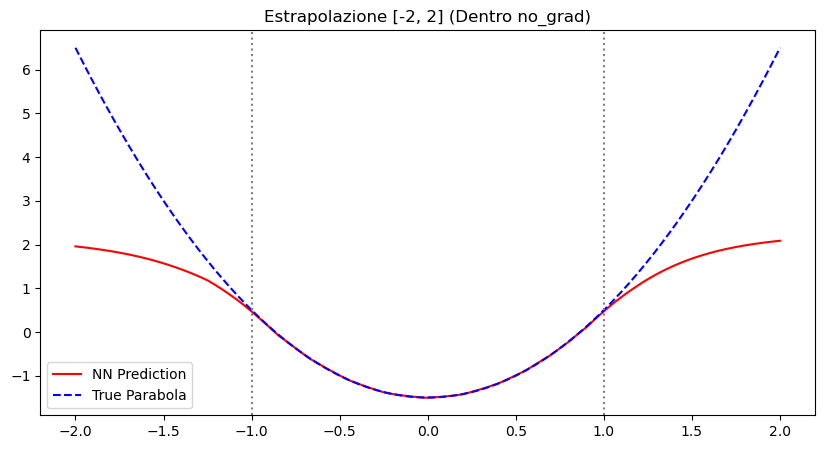

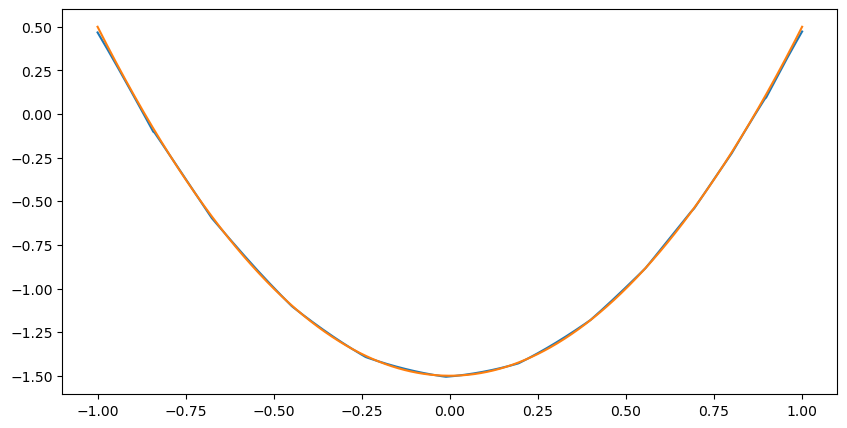

In [ ]:
import torch
from torch import nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


class NNParabola(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        # DEFINE HERE THE LAYERS
        self.layers = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.Tanh(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, output_size)
            nn.Sigmoid()
        )
        
        #DEFINE HERE THE OPTIMIZER
        self.optimizer = optim.Adam(self.parameters(), lr=0.01)

        #DEFINE HERE THE LOSS
        self.criterion = nn.MSELoss()

    def forward(self, x):
        #DEFINE HERE THE MODEL
        output = self.layers(x)
        return output

    def train_step(self, inputs, labels):
        # zero the parameter gradients
        self.optimizer.zero_grad()

        # forward + backward + optimize
        outputs = self.forward(inputs)
        labels = labels.unsqueeze(1)

        loss = self.criterion(outputs, labels)
        loss.backward()

        self.optimizer.step()

        return loss.item()


def parabola(x, a=2, b=0, c=-1.5):
    return a*x**2 + b*x + c


def main():
    input_size = 1
    output_size = 1

    # Load the data:
    x_data, y_data = np.load('parabola.npz')['x'], np.load('parabola.npz')['y']
    # Reshape the x data as .reshape(len(x_data), 1)
    x_data = torch.tensor(x_data, dtype=torch.float32).reshape(len(x_data), 1)
    y_data = torch.tensor(y_data, dtype=torch.float32)

    # Splitting the dataset into train and test one:
    x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2)
    
    # Dataset loader creation:
    dataset_train = TensorDataset(x_train, y_train)
    loader_train = DataLoader(dataset_train, batch_size=50, shuffle=True)

    # Define the model
    nn_model = NNParabola(input_size, output_size)

    loss_evolution = []
    
    # Train the model
    n_of_epochs = 200
    print("Inizio dell'addestramento...")
    for epoch in range(n_of_epochs):
        loss_batches = []
        # Estraiamo per ogni mini-batch i dati di input e le rispettive labels
        for inputs, labels in loader_train:
            loss = nn_model.train_step(inputs, labels)
            loss_batches.append(loss)
            
        # Salviamo la loss media per l'epoca corrente
        mean_loss = np.mean(loss_batches)
        loss_evolution.append(mean_loss)
        
        # Print metrics sometimes
        if (epoch + 1) % 20 == 0:
            print("Epoca: {:3d}/{}, Loss: {:.4f}".format(epoch + 1, n_of_epochs, mean_loss))

    #Plot  Loss
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, n_of_epochs + 1), loss_evolution, color='red', label="MSE Loss")
    plt.title("Evoluzione dell'Errore durante l'addestramento")
    plt.xlabel("Epoche")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    with torch.no_grad():
        # generate input data in the range [-2,2] and query the NN and plot the predictions
        x_ext = torch.linspace(-2, 2, 1000)
        x_ext = torch.reshape(x_ext, shape=(x_ext.size()[0], 1))
        y_ext = nn_model(x_ext)
        
        plt.figure(figsize=(10, 5))
        plt.plot(x_ext.numpy(), y_ext.numpy(), label="NN Prediction", color="red")
        plt.plot(x_ext.numpy(), parabola(x_ext.numpy()), label="True Parabola", color="blue", linestyle="--")
        
        # Lines for interval [-1,1]
        plt.axvline(x=-1, color='gray', linestyle=':')
        plt.axvline(x=1, color='gray', linestyle=':')
        
        plt.title("Estrapolazione [-2, 2] (Dentro no_grad)")
        plt.legend()
        plt.show()
    

    x = torch.linspace(-1, 1, 1000)
    x = torch.reshape(x, shape=(x.size()[0], 1))
    y = nn_model(x)

    plt.figure(figsize=(10, 5))
    plt.plot(x.detach().numpy(), y.detach().numpy())
    plt.plot(x.detach().numpy(), parabola(x))
    plt.show()

if __name__ == "__main__":
    main()